In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
np.random.seed(0)

class FCNN:
    def __init__(self, layer_sizes, hidden_act='tanh', out_act='logistic', lr=0.01, epochs=800, tol=1e-4):
        self.layer_sizes = layer_sizes
        self.hidden_act = hidden_act
        self.out_act = out_act
        self.lr = lr
        self.epochs = epochs
        self.tol = tol
        self.loss_history = []
        
        # Xavier Initialization: N(0, 1/fan_in)
        self.W = []
        self.b = []
        for i in range(len(layer_sizes) - 1):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            self.W.append(np.random.randn(fan_in, fan_out) * np.sqrt(1.0 / fan_in))
            self.b.append(np.zeros(fan_out))

    def _act(self, z, kind):
        if kind == 'tanh':
            return np.tanh(z)
        elif kind == 'logistic':
            z_clipped = np.clip(z, -250, 250)
            return 1.0 / (1.0 + np.exp(-z_clipped))
        return z

    def _dact(self, a, kind):
        if kind == 'tanh':
            return 1.0 - a**2
        elif kind == 'logistic':
            return a * (1.0 - a)
        return np.ones_like(a)

    def _forward(self, X):
        As = [X]
        Zs = []
        A = X
        for i in range(len(self.W)):
            Z = A @ self.W[i] + self.b[i]
            Zs.append(Z)
            kind = self.out_act if i == len(self.W) - 1 else self.hidden_act
            A = self._act(Z, kind)
            As.append(A)
        return As, Zs

    def compute_loss(self, X, y_onehot):
        As, _ = self._forward(X)
        err = y_onehot - As[-1]
        return np.mean(0.5 * np.sum(err**2, axis=1))

    def train_sgd(self, X, y_onehot):
        n = X.shape[0]
        self.loss_history = []
        prev_loss = float('inf')
        
        for epoch in range(self.epochs):
            idx = np.random.permutation(n)
            for j in idx:
                x = X[j:j+1]
                target = y_onehot[j:j+1]
                As, _ = self._forward(x)
                
                # Instantaneous squared error: 0.5 * sum((target - out)^2)
                dA = As[-1] - target
                
                for i in range(len(self.W) - 1, -1, -1):
                    kind = self.out_act if i == len(self.W) - 1 else self.hidden_act
                    dZ = dA * self._dact(As[i + 1], kind)
                    dW = As[i].T @ dZ
                    db = dZ[0]
                    if i > 0:
                        dA = dZ @ self.W[i].T
                    self.W[i] -= self.lr * dW
                    self.b[i] -= self.lr * db
                    
            epoch_loss = self.compute_loss(X, y_onehot)
            self.loss_history.append(epoch_loss)
            
            # Convergence Criterion
            if abs(prev_loss - epoch_loss) < self.tol:
                break
            prev_loss = epoch_loss

    def predict(self, X):
        As, _ = self._forward(X)
        return np.argmax(As[-1], axis=1)

    def count_parameters(self):
        return sum(w.size for w in self.W) + sum(b.size for b in self.b)

In [2]:
def prepare_data_60_20_20(class_data_list):
    X_tr, y_tr, X_val, y_val, X_te, y_te = [], [], [], [], [], []
    for label, data in enumerate(class_data_list):
        n = data.shape[0]
        n_tr = int(n * 0.6)
        n_val = int(n * 0.2)
        X_tr.append(data[:n_tr])
        y_tr.append(np.full(n_tr, label))
        X_val.append(data[n_tr:n_tr + n_val])
        y_val.append(np.full(n_val, label))
        X_te.append(data[n_tr + n_val:])
        y_te.append(np.full(n - n_tr - n_val, label))
        
    X_tr = np.vstack(X_tr)
    y_tr = np.concatenate(y_tr)
    X_val = np.vstack(X_val)
    y_val = np.concatenate(y_val)
    X_te = np.vstack(X_te)
    y_te = np.concatenate(y_te)
    
    # Feature Standardization fit on Train
    mu = X_tr.mean(axis=0)
    sigma = X_tr.std(axis=0) + 1e-8
    return (X_tr - mu) / sigma, y_tr, (X_val - mu) / sigma, y_val, (X_te - mu) / sigma, y_te

def to_onehot(y, C=3):
    oh = np.zeros((len(y), C))
    oh[np.arange(len(y)), y.astype(int)] = 1.0
    return oh

def evaluate_metrics(y_true, y_pred, C=3, print_title=None):
    cm = np.zeros((C, C), int)
    for t, p in zip(y_true, y_pred):
        cm[int(t), int(p)] += 1
    acc = np.trace(cm) / cm.sum()
    precs, recs, f1s = [], [], []
    for i in range(C):
        tp = cm[i, i]
        fp = cm[:, i].sum() - tp
        fn = cm[i, :].sum() - tp
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        precs.append(prec)
        recs.append(rec)
        f1s.append(f1)
        
    mean_prec, mean_rec, mean_f1 = np.mean(precs), np.mean(recs), np.mean(f1s)
    
    if print_title:
        print(f"--- {print_title} ---")
        print(f"Confusion Matrix:\n{cm}")
        print(f"Accuracy: {acc*100:.2f}%")
        for i in range(C):
            print(f"  Class {i} -> Precision: {precs[i]:.2f}, Recall: {recs[i]:.2f}, F1: {f1s[i]:.2f}")
        print(f"  Mean Precision: {mean_prec:.2f} | Mean Recall: {mean_rec:.2f} | Mean F1: {mean_f1:.2f}\n")
        
    return acc, cm, precs, recs, f1s, mean_prec, mean_rec, mean_f1

In [3]:
def plot_decision_regions(X, y, model, title):
    plt.figure(figsize=(6, 5))
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='coolwarm', s=20)
    plt.title(title)
    plt.xlabel('Feature 1 (Standardized)')
    plt.ylabel('Feature 2 (Standardized)')
    plt.tight_layout()
    plt.show()

def plot_hidden_surfaces(model, X, y, title_prefix):
    n_hidden_layers = len(model.layer_sizes) - 2
    for h in range(1, n_hidden_layers + 1):
        n_nodes = model.layer_sizes[h]
        for node in range(n_nodes):
            fig = plt.figure(figsize=(5, 4))
            ax = fig.add_subplot(111, projection='3d')
            x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
            y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
            gx, gy = np.meshgrid(np.linspace(x_min, x_max, 25), np.linspace(y_min, y_max, 25))
            grid = np.c_[gx.ravel(), gy.ravel()]
            
            As, _ = model._forward(grid)
            gz = As[h][:, node].reshape(gx.shape)
            ax.plot_surface(gx, gy, gz, alpha=0.6, cmap='viridis')
            
            As_data, _ = model._forward(X)
            ax.scatter(X[:, 0], X[:, 1], As_data[h][:, node], c=y, cmap='coolwarm', s=10, edgecolor='k', alpha=0.8)
            ax.set_xlabel('Feature 1')
            ax.set_ylabel('Feature 2')
            ax.set_zlabel(f'H{h}N{node} Output')
            ax.set_title(f'{title_prefix} - Hidden {h}, Node {node}')
            plt.tight_layout()
            plt.show()

    for out in range(model.layer_sizes[-1]):
        fig = plt.figure(figsize=(5, 4))
        ax = fig.add_subplot(111, projection='3d')
        x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
        y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
        gx, gy = np.meshgrid(np.linspace(x_min, x_max, 25), np.linspace(y_min, y_max, 25))
        grid = np.c_[gx.ravel(), gy.ravel()]
        
        As, _ = model._forward(grid)
        gz = As[-1][:, out].reshape(gx.shape)
        ax.plot_surface(gx, gy, gz, alpha=0.6, cmap='coolwarm')
        
        As_data, _ = model._forward(X)
        ax.scatter(X[:, 0], X[:, 1], As_data[-1][:, out], c=y, cmap='coolwarm', s=10, edgecolor='k', alpha=0.8)
        ax.set_xlabel('Feature 1')
        ax.set_ylabel('Feature 2')
        ax.set_zlabel(f'Output {out}')
        ax.set_title(f'{title_prefix} - Output Node {out}')
        plt.tight_layout()
        plt.show()

In [4]:
def resolve_path(candidates):
    for p in candidates:
        if os.path.exists(p): return p
    raise FileNotFoundError(f"Checked: {candidates}")

p_ls_c1 = resolve_path(['Classification/LS_Group24/Class1.txt', 'Classification/LS_Group24/class1.txt', 'data/Classification/LS_Group24/Class1.txt'])
p_ls_c2 = resolve_path(['Classification/LS_Group24/Class2.txt', 'Classification/LS_Group24/class2.txt', 'data/Classification/LS_Group24/Class2.txt'])
p_ls_c3 = resolve_path(['Classification/LS_Group24/Class3.txt', 'Classification/LS_Group24/class3.txt', 'data/Classification/LS_Group24/Class3.txt'])
p_nls = resolve_path(['Classification/NLS_Group24.txt', 'data/Classification/NLS_Group24.txt'])

ls_c1 = np.loadtxt(p_ls_c1)
ls_c2 = np.loadtxt(p_ls_c2)
ls_c3 = np.loadtxt(p_ls_c3)
nls_data = np.loadtxt(p_nls, skiprows=1)
nls_c1, nls_c2, nls_c3 = nls_data[:300], nls_data[300:800], nls_data[800:1800]

Xtr_ls, ytr_ls, Xval_ls, yval_ls, Xte_ls, yte_ls = prepare_data_60_20_20([ls_c1, ls_c2, ls_c3])
Xtr_nls, ytr_nls, Xval_nls, yval_nls, Xte_nls, yte_nls = prepare_data_60_20_20([nls_c1, nls_c2, nls_c3])

print(f"Linearly Separable -> Train: {len(Xtr_ls)}, Val: {len(Xval_ls)}, Test: {len(Xte_ls)}")
print(f"Non-Linearly Separable -> Train: {len(Xtr_nls)}, Val: {len(Xval_nls)}, Test: {len(Xte_nls)}")

Linearly Separable -> Train: 900, Val: 300, Test: 300
Non-Linearly Separable -> Train: 1080, Val: 360, Test: 360


In [5]:
# Architectures for LS: 1 hidden layer with different nodes
ls_configs = [[2, 4, 3], [2, 8, 3], [2, 16, 3]]
ls_results = []

print("==========================================================================")
print("EVALUATING ALL ARCHITECTURES ON VALIDATION SET (DATASET 1: LINEARLY SEPARABLE)")
print("==========================================================================\n")

for cfg in ls_configs:
    np.random.seed(0)
    m = FCNN(cfg, hidden_act='tanh', out_act='logistic', lr=0.01, epochs=800, tol=1e-4)
    m.train_sgd(Xtr_ls, to_onehot(ytr_ls))
    val_loss = m.compute_loss(Xval_ls, to_onehot(yval_ls))
    acc, cm, precs, recs, f1s, mp, mr, mf = evaluate_metrics(
        yval_ls, m.predict(Xval_ls), print_title=f"Validation Performance: Architecture {cfg}"
    )
    ls_results.append((cfg, m, acc, cm, precs, recs, f1s, mp, mr, mf, val_loss))

# Tie-Breaking Rule: (Accuracy -> Lower Val Loss -> Fewer Parameters)
def model_rank_key(item):
    cfg, model, acc, cm, precs, recs, f1s, mp, mr, mf, val_loss = item
    return (acc, -val_loss, -model.count_parameters())

best_ls_item = max(ls_results, key=model_rank_key)
best_ls_cfg, best_ls_model = best_ls_item[0], best_ls_item[1]

print("==========================================================================")
print(f"SELECTED BEST LS ARCHITECTURE: {best_ls_cfg}")
print(f"Tie-Breaking Justification: Val Acc = {best_ls_item[2]*100:.2f}%, Val Loss = {best_ls_item[10]:.5f}, Parameters = {best_ls_model.count_parameters()}")
print("==========================================================================\n")

# Summary Table for LaTeX Report
summary_rows = []
for item in ls_results:
    cfg, m, acc, _, _, _, _, mp, mr, mf, vloss = item
    summary_rows.append({
        "Architecture": str(cfg),
        "Parameters": m.count_parameters(),
        "Val Loss (MSE)": f"{vloss:.5f}",
        "Val Accuracy (%)": f"{acc*100:.2f}%",
        "Mean Precision": f"{mp:.2f}",
        "Mean Recall": f"{mr:.2f}",
        "Mean F1": f"{mf:.2f}"
    })
display(pd.DataFrame(summary_rows))

EVALUATING ALL ARCHITECTURES ON VALIDATION SET (DATASET 1: LINEARLY SEPARABLE)

--- Validation Performance: Architecture [2, 4, 3] ---
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  0   0 100]]
Accuracy: 100.00%
  Class 0 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

--- Validation Performance: Architecture [2, 8, 3] ---
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  1   0  99]]
Accuracy: 99.67%
  Class 0 -> Precision: 0.99, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 0.99, F1: 0.99
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

--- Validation Performance: Architecture [2, 16, 3] ---
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  1   0  99]]
Accuracy: 99.67%
  Class 0 -> Precision: 0.99, Recall: 1.00, F1: 1.00
  Class 1 -> Precis

,Architecture,Parameters,Val Loss (MSE),Val Accuracy (%),Mean Precision,Mean Recall,Mean F1
0,"[2, 4, 3]",27,0.00497,100.00%,1.00,1.00,1.00
1,"[2, 8, 3]",51,0.00455,99.67%,1.00,1.00,1.00
2,"[2, 16, 3]",99,0.00454,99.67%,1.00,1.00,1.00


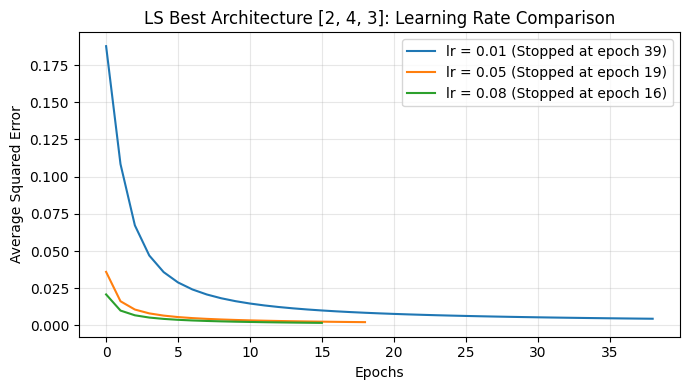

In [6]:
learning_rates = [0.01, 0.05, 0.08]
lr_histories = {}

plt.figure(figsize=(7, 4))
for lr in learning_rates:
    np.random.seed(0)
    m = FCNN(best_ls_cfg, hidden_act='tanh', out_act='logistic', lr=lr, epochs=800, tol=1e-4)
    m.train_sgd(Xtr_ls, to_onehot(ytr_ls))
    lr_histories[lr] = m.loss_history
    plt.plot(m.loss_history, label=f'lr = {lr} (Stopped at epoch {len(m.loss_history)})')

plt.title(f'LS Best Architecture {best_ls_cfg}: Learning Rate Comparison')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

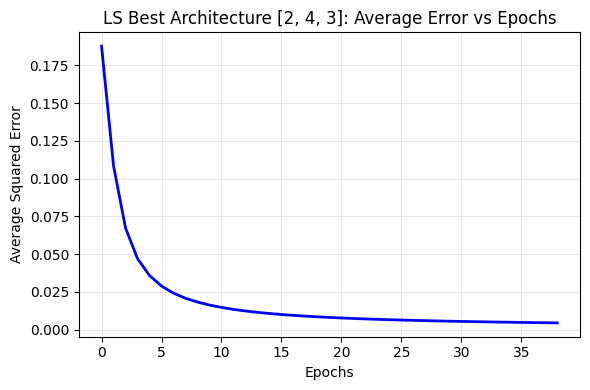

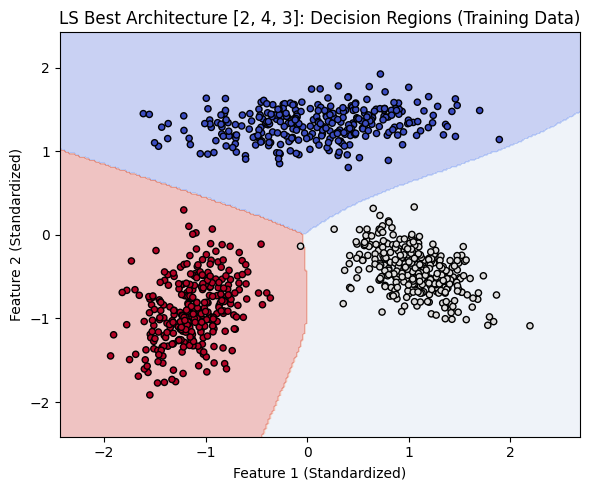

--- Test Evaluation for Best LS Model [2, 4, 3] ---
Confusion Matrix:
[[100   0   0]
 [  0 100   0]
 [  1   0  99]]
Accuracy: 99.67%
  Class 0 -> Precision: 0.99, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 0.99, F1: 0.99
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

Displaying Node Activation Surfaces for LS Test Set:


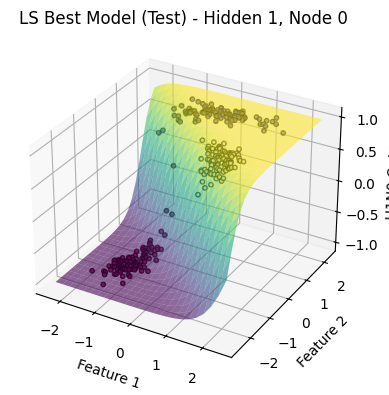

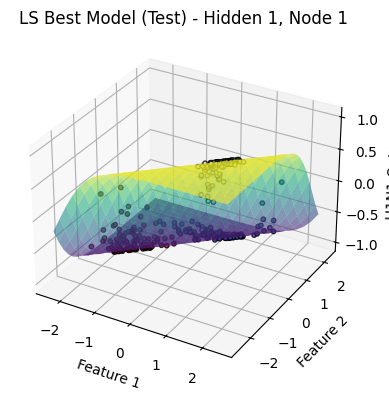

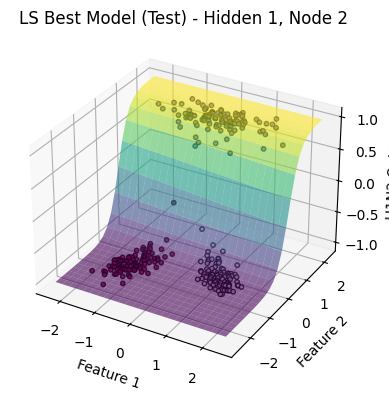

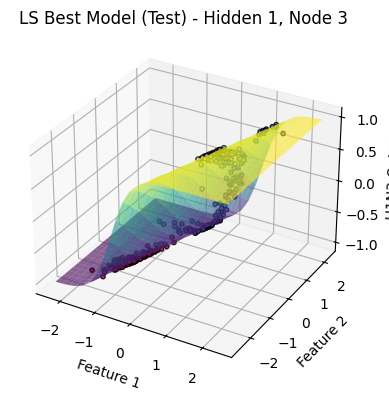

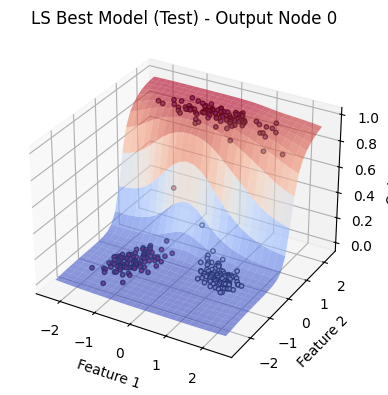

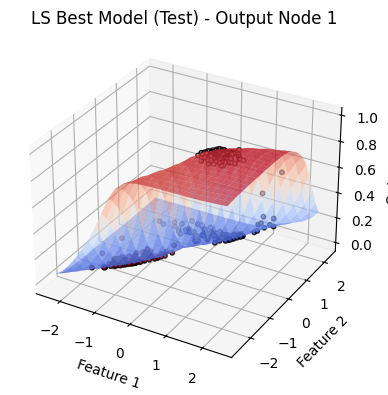

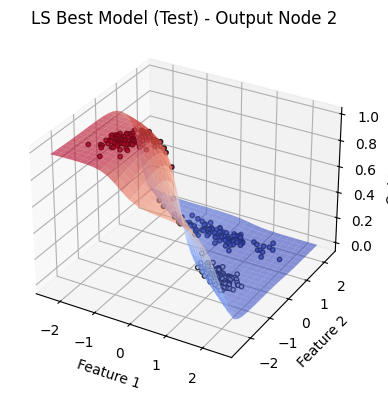

In [7]:
# 1. Average Error vs Epochs for Best Model
plt.figure(figsize=(6, 4))
plt.plot(best_ls_model.loss_history, color='blue', lw=2)
plt.title(f'LS Best Architecture {best_ls_cfg}: Average Error vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Decision Regions on Training Data
plot_decision_regions(Xtr_ls, ytr_ls, best_ls_model, f'LS Best Architecture {best_ls_cfg}: Decision Regions (Training Data)')

# 3. Test Evaluation for Best Architecture
evaluate_metrics(yte_ls, best_ls_model.predict(Xte_ls), print_title=f"Test Evaluation for Best LS Model {best_ls_cfg}")

# 4. Hidden Node & Output Node 3D Surfaces
print("Displaying Node Activation Surfaces for LS Test Set:")
plot_hidden_surfaces(best_ls_model, Xte_ls, yte_ls, "LS Best Model (Test)")

In [8]:
# Architectures for NLS: 2 hidden layers
nls_configs = [[2, 4, 4, 3], [2, 8, 4, 3], [2, 8, 8, 3], [2, 16, 8, 3]]
nls_results = []

print("==========================================================================")
print("EVALUATING ALL ARCHITECTURES ON VALIDATION SET (DATASET 2: NON-LINEARLY SEPARABLE)")
print("==========================================================================\n")

for cfg in nls_configs:
    np.random.seed(0)
    m = FCNN(cfg, hidden_act='tanh', out_act='logistic', lr=0.01, epochs=800, tol=1e-4)
    m.train_sgd(Xtr_nls, to_onehot(ytr_nls))
    val_loss = m.compute_loss(Xval_nls, to_onehot(yval_nls))
    acc, cm, precs, recs, f1s, mp, mr, mf = evaluate_metrics(
        yval_nls, m.predict(Xval_nls), print_title=f"Validation Performance: Architecture {cfg}"
    )
    nls_results.append((cfg, m, acc, cm, precs, recs, f1s, mp, mr, mf, val_loss))

best_nls_item = max(nls_results, key=model_rank_key)
best_nls_cfg, best_nls_model = best_nls_item[0], best_nls_item[1]

print("==========================================================================")
print(f"SELECTED BEST NLS ARCHITECTURE: {best_nls_cfg}")
print(f"Tie-Breaking Justification: Val Acc = {best_nls_item[2]*100:.2f}%, Val Loss = {best_nls_item[10]:.5f}, Parameters = {best_nls_model.count_parameters()}")
print("==========================================================================\n")

# Summary Table
summary_rows_nls = []
for item in nls_results:
    cfg, m, acc, _, _, _, _, mp, mr, mf, vloss = item
    summary_rows_nls.append({
        "Architecture": str(cfg),
        "Parameters": m.count_parameters(),
        "Val Loss (MSE)": f"{vloss:.5f}",
        "Val Accuracy (%)": f"{acc*100:.2f}%",
        "Mean Precision": f"{mp:.2f}",
        "Mean Recall": f"{mr:.2f}",
        "Mean F1": f"{mf:.2f}"
    })
display(pd.DataFrame(summary_rows_nls))

EVALUATING ALL ARCHITECTURES ON VALIDATION SET (DATASET 2: NON-LINEARLY SEPARABLE)

--- Validation Performance: Architecture [2, 4, 4, 3] ---
Confusion Matrix:
[[ 60   0   0]
 [  0 100   0]
 [  0   0 200]]
Accuracy: 100.00%
  Class 0 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

--- Validation Performance: Architecture [2, 8, 4, 3] ---
Confusion Matrix:
[[ 60   0   0]
 [  0 100   0]
 [  0   0 200]]
Accuracy: 100.00%
  Class 0 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

--- Validation Performance: Architecture [2, 8, 8, 3] ---
Confusion Matrix:
[[ 60   0   0]
 [  0 100   0]
 [  0   0 200]]
Accuracy: 100.00%
  Class 0 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Cla

,Architecture,Parameters,Val Loss (MSE),Val Accuracy (%),Mean Precision,Mean Recall,Mean F1
0,"[2, 4, 4, 3]",47,0.00502,100.00%,1.00,1.00,1.00
1,"[2, 8, 4, 3]",75,0.00520,100.00%,1.00,1.00,1.00
2,"[2, 8, 8, 3]",123,0.00377,100.00%,1.00,1.00,1.00
3,"[2, 16, 8, 3]",211,0.00342,100.00%,1.00,1.00,1.00


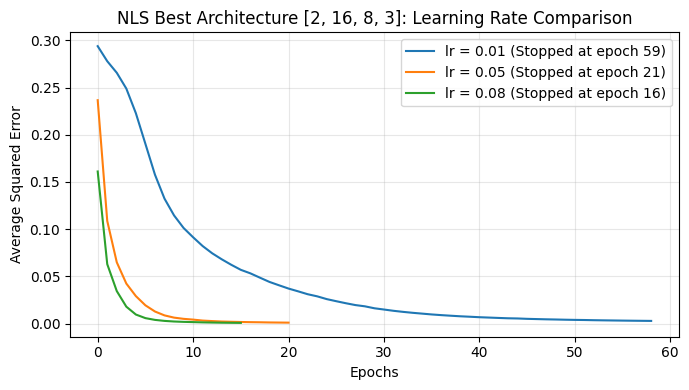

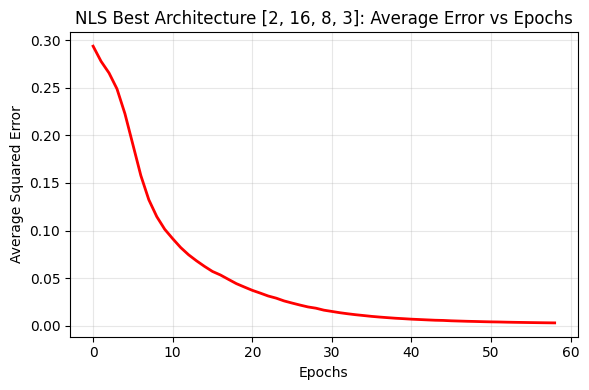

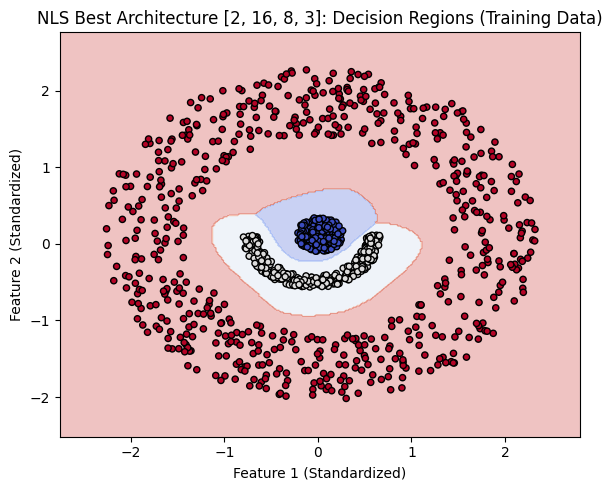

--- Test Evaluation for Best NLS Model [2, 16, 8, 3] ---
Confusion Matrix:
[[ 60   0   0]
 [  0 100   0]
 [  0   0 200]]
Accuracy: 100.00%
  Class 0 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 1 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Class 2 -> Precision: 1.00, Recall: 1.00, F1: 1.00
  Mean Precision: 1.00 | Mean Recall: 1.00 | Mean F1: 1.00

Displaying Node Activation Surfaces for NLS Test Set:


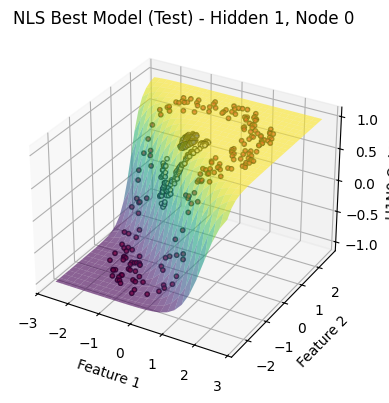

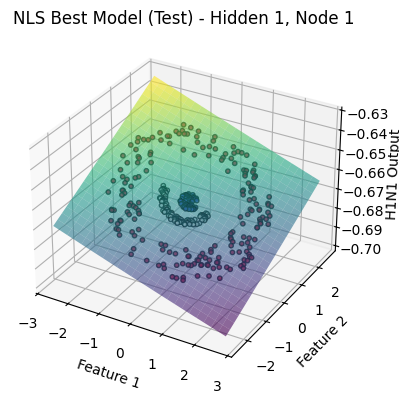

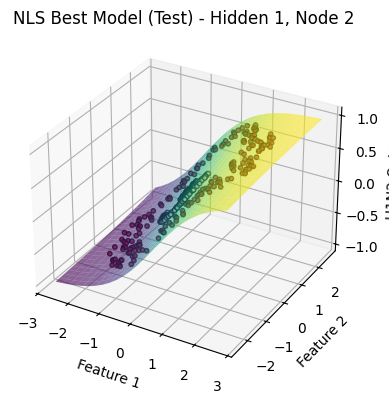

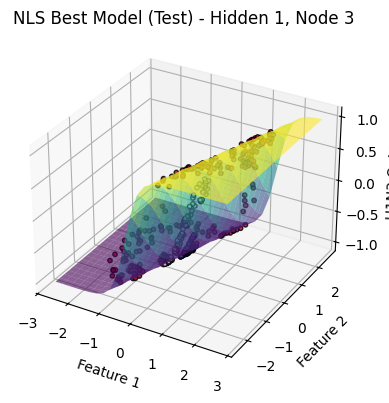

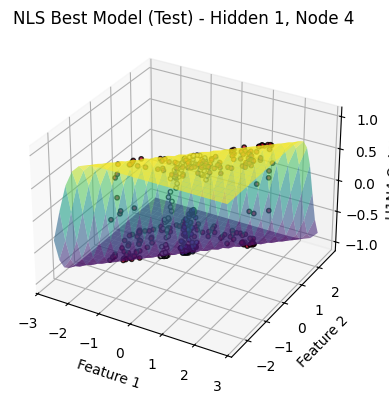

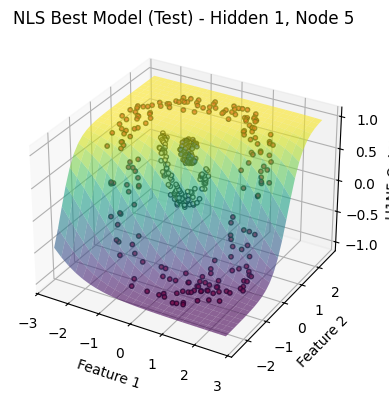

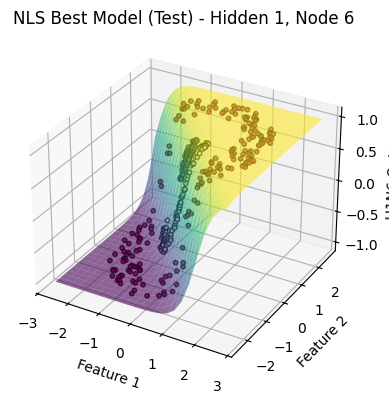

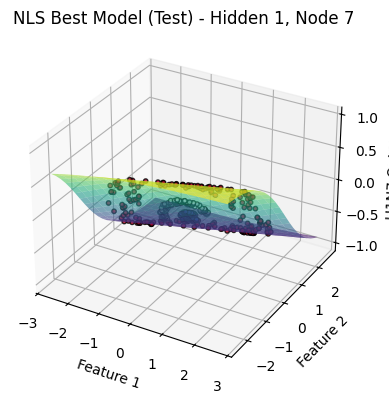

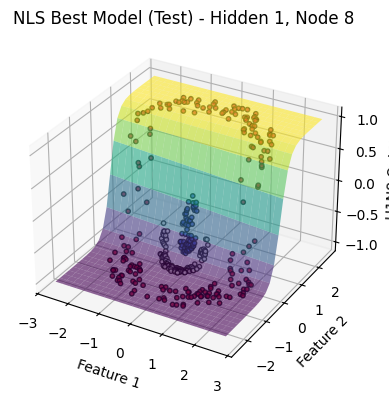

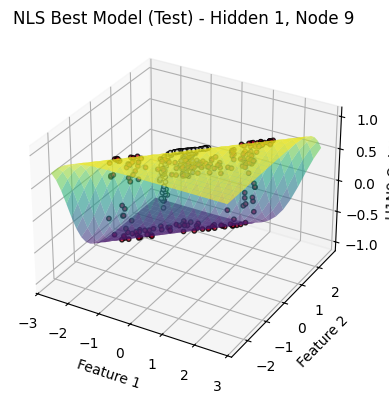

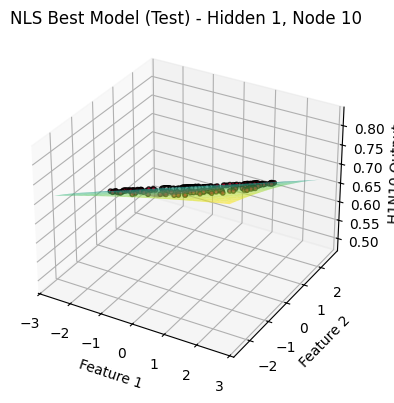

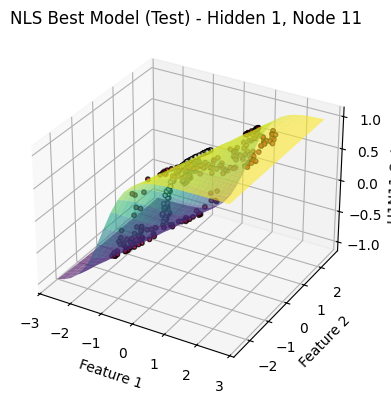

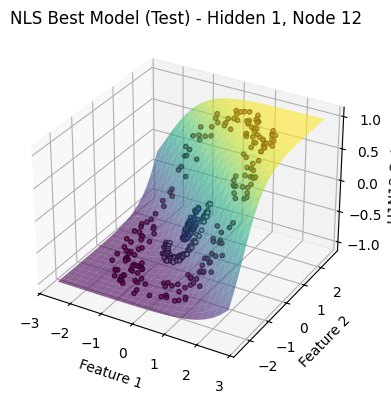

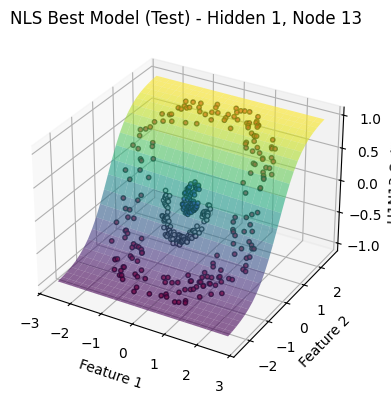

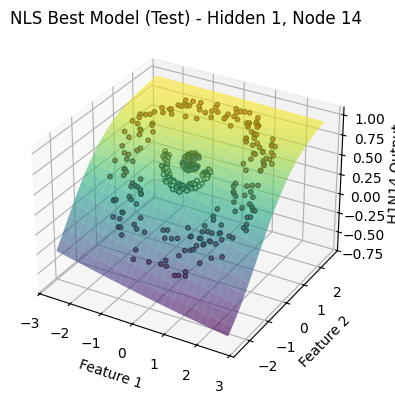

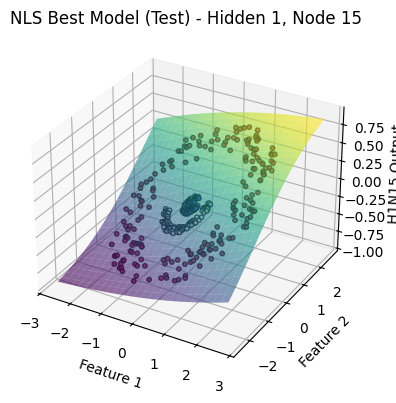

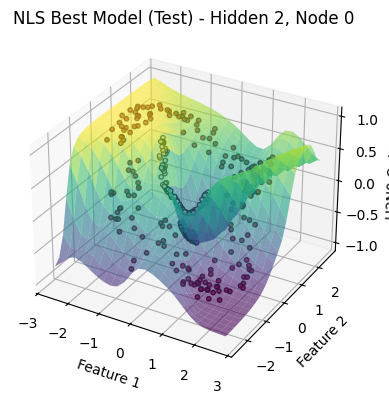

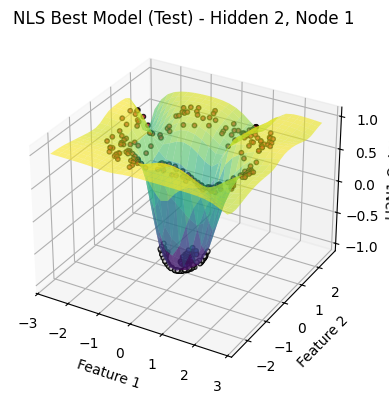

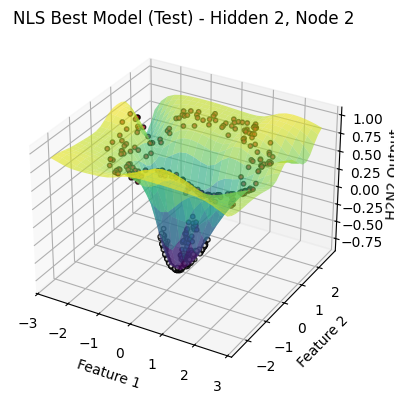

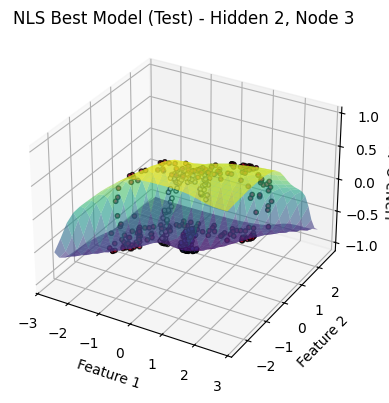

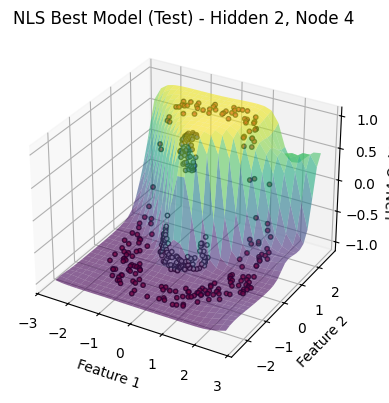

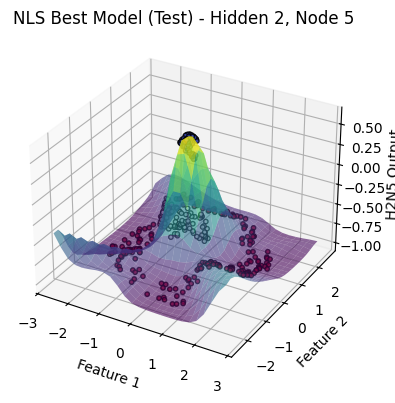

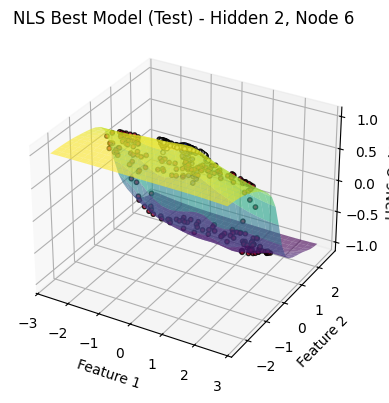

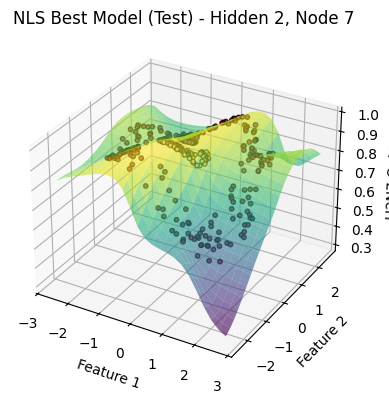

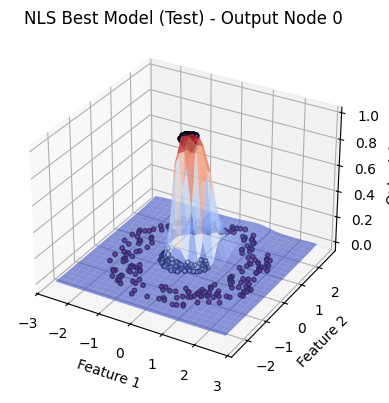

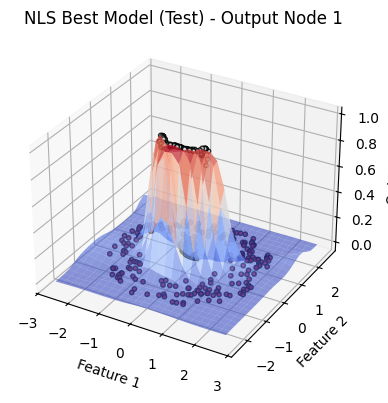

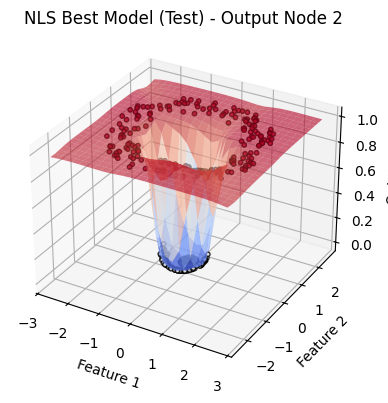

In [9]:
# Learning Rate Comparison for Best NLS
plt.figure(figsize=(7, 4))
for lr in [0.01, 0.05, 0.08]:
    np.random.seed(0)
    m = FCNN(best_nls_cfg, hidden_act='tanh', out_act='logistic', lr=lr, epochs=800, tol=1e-4)
    m.train_sgd(Xtr_nls, to_onehot(ytr_nls))
    plt.plot(m.loss_history, label=f'lr = {lr} (Stopped at epoch {len(m.loss_history)})')

plt.title(f'NLS Best Architecture {best_nls_cfg}: Learning Rate Comparison')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Best Model Error vs Epochs
plt.figure(figsize=(6, 4))
plt.plot(best_nls_model.loss_history, color='red', lw=2)
plt.title(f'NLS Best Architecture {best_nls_cfg}: Average Error vs Epochs')
plt.xlabel('Epochs')
plt.ylabel('Average Squared Error')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Decision Regions
plot_decision_regions(Xtr_nls, ytr_nls, best_nls_model, f'NLS Best Architecture {best_nls_cfg}: Decision Regions (Training Data)')

# Test Evaluation
evaluate_metrics(yte_nls, best_nls_model.predict(Xte_nls), print_title=f"Test Evaluation for Best NLS Model {best_nls_cfg}")

# Surfaces
print("Displaying Node Activation Surfaces for NLS Test Set:")
plot_hidden_surfaces(best_nls_model, Xte_nls, yte_nls, "NLS Best Model (Test)")

In [12]:
# Comparison with Single-Neuron Baseline (Assignment 1)
class SingleNeuronPerceptron:
    def __init__(self, d, lr=0.01, epochs=800):
        self.w = np.random.randn(d + 1) * 0.01
        self.lr = lr
        self.epochs = epochs
    def train(self, X, y):
        n = len(X); Xa = np.c_[np.ones(n), X]
        for _ in range(self.epochs):
            z = Xa @ self.w
            a = 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))
            self.w -= self.lr * (Xa.T @ (-(y - a) * a * (1.0 - a))) / n
    def predict(self, X):
        a = 1.0 / (1.0 + np.exp(-np.clip(np.c_[np.ones(len(X)), X] @ self.w, -250, 250)))
        return np.where(a >= 0.5, 1, 0)

class SingleNeuronOVO:
    def __init__(self):
        self.models = {}
    def train(self, X, y):
        for i in range(3):
            for j in range(i + 1, 3):
                idx = np.where((y == i) | (y == j))[0]
                m = SingleNeuronPerceptron(X.shape[1])
                m.train(X[idx], np.where(y[idx] == i, 1, 0))
                self.models[(i, j)] = m
    def predict(self, X):
        votes = np.zeros((len(X), 3))
        for (i, j), m in self.models.items():
            p = m.predict(X)
            for k in range(len(X)): votes[k, i if p[k] == 1 else j] += 1
        return np.argmax(votes, axis=1)

# Train and evaluate baselines
sn_ls = SingleNeuronOVO(); sn_ls.train(Xtr_ls, ytr_ls)
sn_acc_ls, _, _, _, _, _, _, _ = evaluate_metrics(yte_ls, sn_ls.predict(Xte_ls), print_title=None)

sn_nls = SingleNeuronOVO(); sn_nls.train(Xtr_nls, ytr_nls)
sn_acc_nls, _, _, _, _, _, _, _ = evaluate_metrics(yte_nls, sn_nls.predict(Xte_nls), print_title=None)

fcnn_acc_ls, _, _, _, _, _, _, _ = evaluate_metrics(yte_ls, best_ls_model.predict(Xte_ls), print_title=None)
fcnn_acc_nls, _, _, _, _, _, _, _ = evaluate_metrics(yte_nls, best_nls_model.predict(Xte_nls), print_title=None)

# Fixed DataFrame: Standardized column keys prevent NaN values
comparison_df = pd.DataFrame([
    {
        "Dataset": "Linearly Separable",
        "Single-Neuron OVO Test Acc (%)": f"{sn_acc_ls*100:.2f}%",
        "Best FCNN Architecture": str(best_ls_cfg),
        "FCNN Test Acc (%)": f"{fcnn_acc_ls*100:.2f}%"
    },
    {
        "Dataset": "Non-Linearly Separable",
        "Single-Neuron OVO Test Acc (%)": f"{sn_acc_nls*100:.2f}%",
        "Best FCNN Architecture": str(best_nls_cfg),
        "FCNN Test Acc (%)": f"{fcnn_acc_nls*100:.2f}%"
    }
])

display(comparison_df)

,Dataset,Single-Neuron OVO Test Acc (%),Best FCNN Architecture,FCNN Test Acc (%)
0,Linearly Separable,99.33%,"[2, 4, 3]",99.67%
1,Non-Linearly Separable,55.56%,"[2, 16, 8, 3]",100.00%
